# Spaceship Titanic - Exploratory Data Analysis (EDA)

Converted from `spaceship_titanic_eda.py`. Run cells in order; each section reproduces the printed stats and plots from the original script.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SETTINGS

In [2]:
FILE_PATH = "train.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

## HELPER FUNCTIONS

In [3]:
def section(title):
    print("\n" + "=" * 75)
    print(title)
    print("=" * 75)


def show_plot():
    plt.tight_layout()
    plt.show()

## 1. LOAD DATA

In [4]:
df = pd.read_csv(FILE_PATH)

section("SPACESHIP TITANIC DATASET - EXPLORATORY DATA ANALYSIS")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
print(df.head())


SPACESHIP TITANIC DATASET - EXPLORATORY DATA ANALYSIS
Rows: 8693
Columns: 14

First 5 rows:
  PassengerId HomePlanet CryoSleep  ... VRDeck               Name  Transported
0     0001_01     Europa     False  ...    0.0    Maham Ofracculy        False
1     0002_01      Earth     False  ...   44.0       Juanna Vines         True
2     0003_01     Europa     False  ...   49.0      Altark Susent        False
3     0003_02     Europa     False  ...  193.0       Solam Susent        False
4     0004_01      Earth     False  ...    2.0  Willy Santantines         True

[5 rows x 14 columns]


## 2. DATASET OVERVIEW

In [5]:
section("1. DATASET OVERVIEW")

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics (numeric columns):")
print(df.describe())

print("\nDuplicate rows:", df.duplicated().sum())


1. DATASET OVERVIEW

Data types:
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

Descriptive statistics (numeric columns):
               Age   RoomService  ...           Spa        VRDeck
count  8514.000000   8512.000000  ...   8510.000000   8505.000000
mean     28.827930    224.687617  ...    311.138778    304.854791
std      14.489021    666.717663  ...   1136.705535   1145.717189
min       0.000000      0.000000  ...      0.000000      0.000000
25%      19.000000      0.000000  ...      0.000000      0.000000
50%      27.000000      0.000000  ...      0.000000      0.000000
75%      38.000000     47.000000  ...     59.000000     46.000000
max      79.000000  14327.000000  ...  22408.

## 3. MISSING VALUES


2. MISSING VALUE ANALYSIS

Missing values:
CryoSleep: 217 (2.5%)
ShoppingMall: 208 (2.4%)
VIP: 203 (2.3%)
HomePlanet: 201 (2.3%)
Name: 200 (2.3%)
Cabin: 199 (2.3%)
VRDeck: 188 (2.2%)
FoodCourt: 183 (2.1%)
Spa: 183 (2.1%)
Destination: 182 (2.1%)
RoomService: 181 (2.1%)
Age: 179 (2.1%)

INSIGHT:
Missing values are spread fairly evenly across most columns (roughly 2% each) rather than concentrated in one feature. This is consistent with values missing at random rather than one specific field being poorly collected.


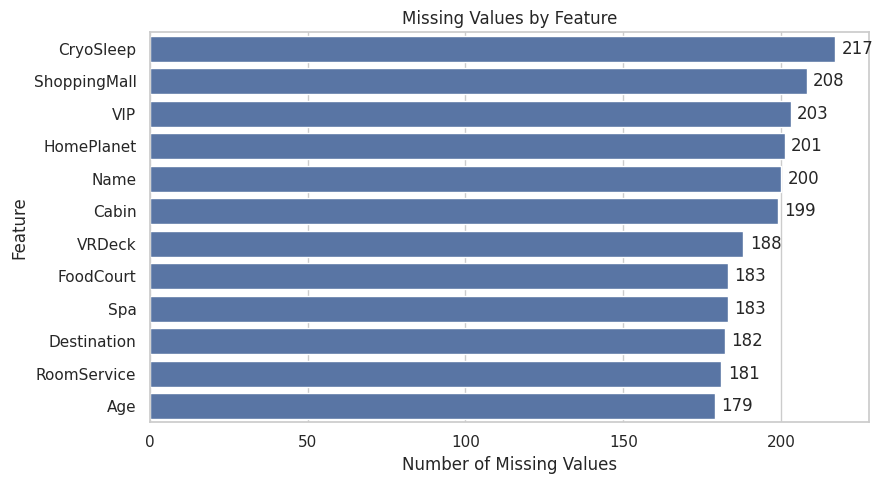

In [6]:
section("2. MISSING VALUE ANALYSIS")

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values:")
for column, count in missing.items():
    print(f"{column}: {count} ({count / len(df) * 100:.1f}%)")

plt.figure()
ax = sns.barplot(x=missing.values, y=missing.index)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

for i, value in enumerate(missing.values):
    ax.text(value + 2, i, str(value), va="center")

show_plot()

print("\nINSIGHT:")
print(
    "Missing values are spread fairly evenly across most columns "
    "(roughly 2% each) rather than concentrated in one feature. "
    "This is consistent with values missing at random rather than "
    "one specific field being poorly collected."
)

## 4. TARGET DISTRIBUTION (TRANSPORTED)


3. TARGET DISTRIBUTION (TRANSPORTED)
Not transported: 4315
Transported: 4378
Overall transported rate: 50.4%

INSIGHT:
50.4% of passengers were transported, while 49.6% were not. The classes are nearly balanced, which is favorable for classification modeling.


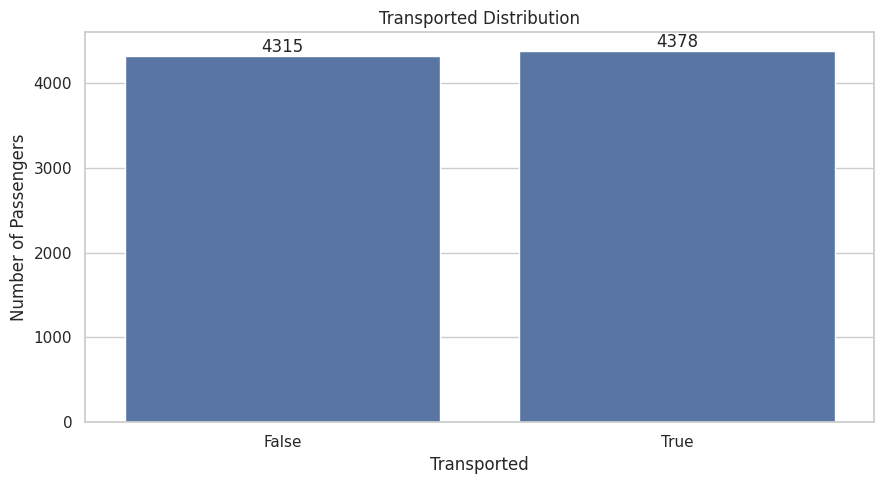

In [7]:
section("3. TARGET DISTRIBUTION (TRANSPORTED)")

transported_counts = df["Transported"].value_counts().sort_index()
transported_rate = df["Transported"].mean()

print(f"Not transported: {transported_counts.get(False, 0)}")
print(f"Transported: {transported_counts.get(True, 0)}")
print(f"Overall transported rate: {transported_rate * 100:.1f}%")

plt.figure()
ax = sns.countplot(data=df, x="Transported")

plt.title("Transported Distribution")
plt.xlabel("Transported")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

show_plot()

print("\nINSIGHT:")
print(
    f"{transported_rate * 100:.1f}% of passengers were transported, while "
    f"{(1 - transported_rate) * 100:.1f}% were not. The classes are "
    "nearly balanced, which is favorable for classification modeling."
)

## 5. HOME PLANET DISTRIBUTION


4. HOME PLANET DISTRIBUTION
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

INSIGHT:
Earth is home to the largest group of passengers, followed by Europa and Mars. Passenger counts alone do not indicate whether home planet is associated with being transported.


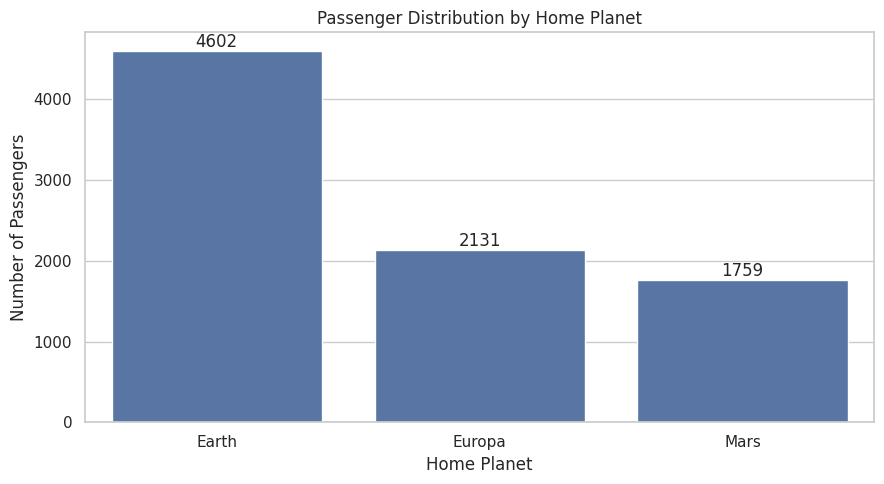

In [8]:
section("4. HOME PLANET DISTRIBUTION")

planet_counts = df["HomePlanet"].value_counts()

print(planet_counts)

plt.figure()
ax = sns.countplot(
    data=df, x="HomePlanet",
    order=planet_counts.index
)

plt.title("Passenger Distribution by Home Planet")
plt.xlabel("Home Planet")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

show_plot()

print("\nINSIGHT:")
print(
    "Earth is home to the largest group of passengers, followed by "
    "Europa and Mars. Passenger counts alone do not indicate whether "
    "home planet is associated with being transported."
)

## 6. TRANSPORTED BY HOME PLANET


5. TRANSPORTED RATE BY HOME PLANET
Earth: 42.4%
Europa: 65.9%
Mars: 52.3%

INSIGHT:
Transported rate differs noticeably by home planet, with Europa passengers transported at a higher rate than Earth passengers. This is an association in the data, not a proven cause.


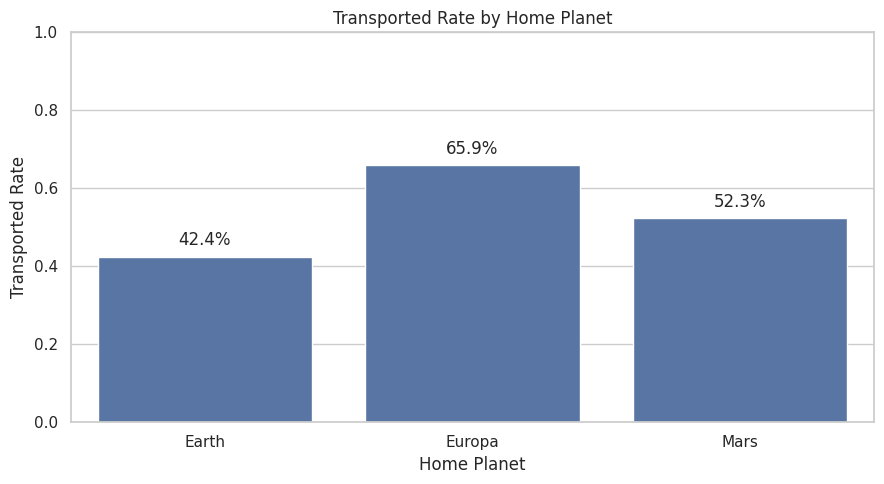

In [9]:
section("5. TRANSPORTED RATE BY HOME PLANET")

transported_by_planet = df.groupby("HomePlanet")["Transported"].mean()

for planet, rate in transported_by_planet.items():
    print(f"{planet}: {rate * 100:.1f}%")

plt.figure()
ax = sns.barplot(
    x=transported_by_planet.index,
    y=transported_by_planet.values
)

plt.title("Transported Rate by Home Planet")
plt.xlabel("Home Planet")
plt.ylabel("Transported Rate")
plt.ylim(0, 1)

for i, value in enumerate(transported_by_planet.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "Transported rate differs noticeably by home planet, with Europa "
    "passengers transported at a higher rate than Earth passengers. "
    "This is an association in the data, not a proven cause."
)

## 7. CRYOSLEEP DISTRIBUTION AND TRANSPORTED


6. CRYOSLEEP AND TRANSPORTED
CryoSleep counts:
CryoSleep
False    5439
True     3037
Name: count, dtype: int64

Transported rate by CryoSleep:
False: 32.9%
True: 81.8%

INSIGHT:
Passengers in CryoSleep were transported at a much higher rate than those who were not. CryoSleep appears to be one of the strongest associations with the target in this dataset.


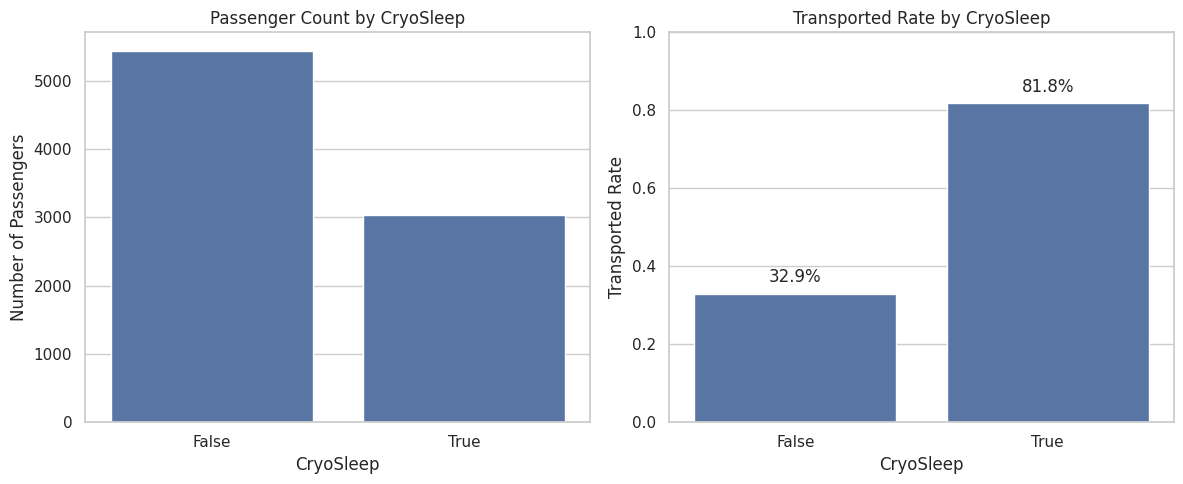

In [10]:
section("6. CRYOSLEEP AND TRANSPORTED")

cryo_counts = df["CryoSleep"].value_counts()
print("CryoSleep counts:")
print(cryo_counts)

transported_by_cryo = df.groupby("CryoSleep")["Transported"].mean()
print("\nTransported rate by CryoSleep:")
for status, rate in transported_by_cryo.items():
    print(f"{status}: {rate * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="CryoSleep", ax=axes[0])
axes[0].set_title("Passenger Count by CryoSleep")
axes[0].set_xlabel("CryoSleep")
axes[0].set_ylabel("Number of Passengers")

sns.barplot(
    x=transported_by_cryo.index,
    y=transported_by_cryo.values,
    ax=axes[1]
)
axes[1].set_title("Transported Rate by CryoSleep")
axes[1].set_xlabel("CryoSleep")
axes[1].set_ylabel("Transported Rate")
axes[1].set_ylim(0, 1)
for i, value in enumerate(transported_by_cryo.values):
    axes[1].text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "Passengers in CryoSleep were transported at a much higher rate "
    "than those who were not. CryoSleep appears to be one of the "
    "strongest associations with the target in this dataset."
)

## 8. DESTINATION AND TRANSPORTED


7. DESTINATION AND TRANSPORTED
Destination counts:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

Transported rate by destination:
55 Cancri e: 61.0%
PSO J318.5-22: 50.4%
TRAPPIST-1e: 47.1%

INSIGHT:
Transported rate varies modestly by destination. The effect appears weaker than CryoSleep or HomePlanet.


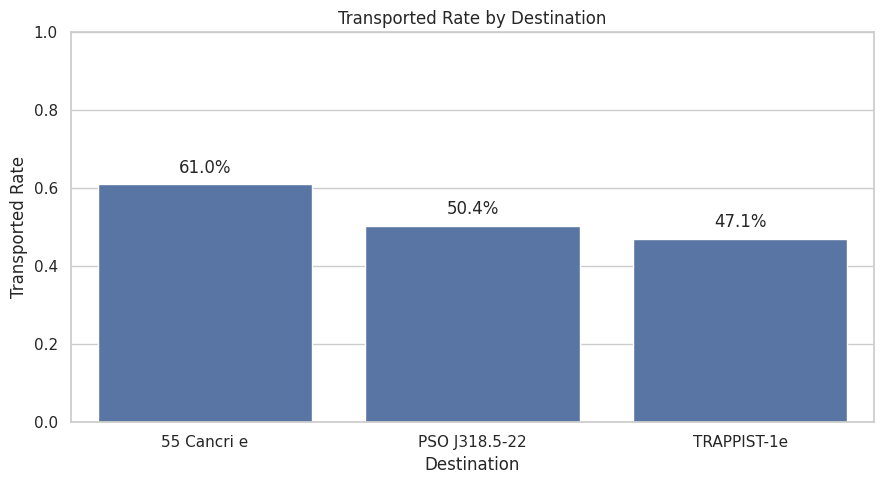

In [11]:
section("7. DESTINATION AND TRANSPORTED")

dest_counts = df["Destination"].value_counts()
print("Destination counts:")
print(dest_counts)

transported_by_dest = df.groupby("Destination")["Transported"].mean()
print("\nTransported rate by destination:")
for dest, rate in transported_by_dest.items():
    print(f"{dest}: {rate * 100:.1f}%")

plt.figure()
ax = sns.barplot(
    x=transported_by_dest.index,
    y=transported_by_dest.values
)

plt.title("Transported Rate by Destination")
plt.xlabel("Destination")
plt.ylabel("Transported Rate")
plt.ylim(0, 1)

for i, value in enumerate(transported_by_dest.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "Transported rate varies modestly by destination. The effect "
    "appears weaker than CryoSleep or HomePlanet."
)

## 9. AGE DISTRIBUTION


8. AGE DISTRIBUTION
Known ages: 8514
Missing ages: 179
Mean: 28.8
Median: 27.0
Minimum: 0.0
Maximum: 79.0

INSIGHT:
The age distribution is concentrated among young adults, with a noticeable spike near age 0 (infants). The graph excludes passengers whose age is missing.


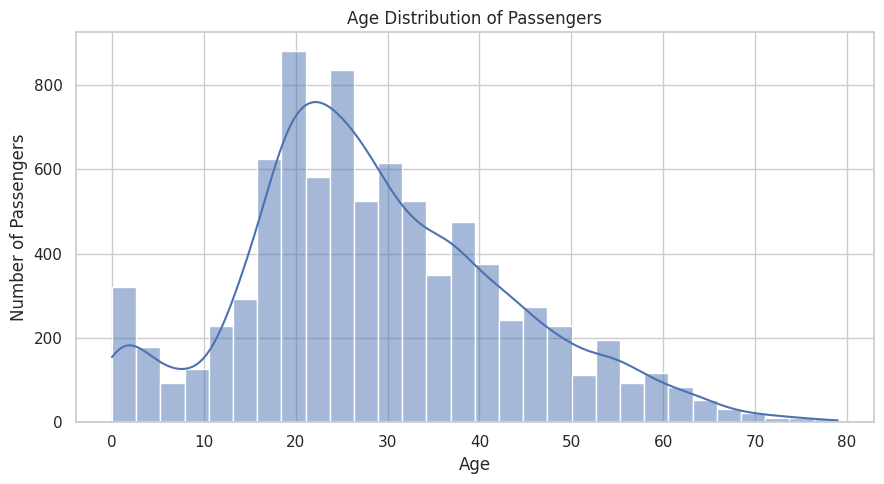

In [12]:
section("8. AGE DISTRIBUTION")

age = df["Age"].dropna()

print(f"Known ages: {len(age)}")
print(f"Missing ages: {df['Age'].isna().sum()}")
print(f"Mean: {age.mean():.1f}")
print(f"Median: {age.median():.1f}")
print(f"Minimum: {age.min():.1f}")
print(f"Maximum: {age.max():.1f}")

plt.figure()
sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

show_plot()

print("\nINSIGHT:")
print(
    "The age distribution is concentrated among young adults, with a "
    "noticeable spike near age 0 (infants). The graph excludes "
    "passengers whose age is missing."
)

## 10. AGE VS TRANSPORTED


9. AGE AND TRANSPORTED
                  mean  median  count
Transported                          
False        29.922858    27.0   4226
True         27.748834    26.0   4288

INSIGHT:
Age distributions for transported and non-transported passengers overlap considerably, suggesting age alone is a weaker predictor than CryoSleep or HomePlanet.


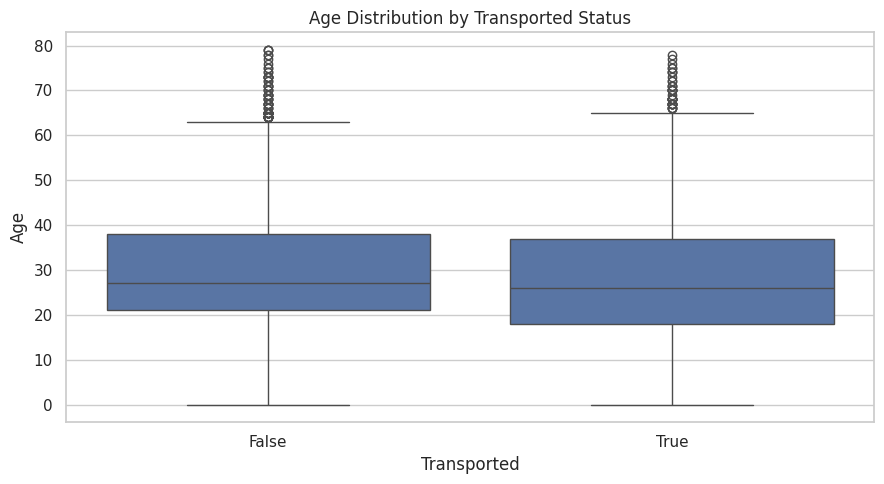

In [13]:
section("9. AGE AND TRANSPORTED")

age_summary = df.groupby("Transported")["Age"].agg(
    ["mean", "median", "count"]
)

print(age_summary)

plt.figure()
sns.boxplot(
    data=df,
    x="Transported",
    y="Age"
)

plt.title("Age Distribution by Transported Status")
plt.xlabel("Transported")
plt.ylabel("Age")

show_plot()

print("\nINSIGHT:")
print(
    "Age distributions for transported and non-transported passengers "
    "overlap considerably, suggesting age alone is a weaker predictor "
    "than CryoSleep or HomePlanet."
)

## 11. VIP STATUS AND TRANSPORTED


10. VIP STATUS AND TRANSPORTED
VIP counts:
VIP
False    8291
True      199
Name: count, dtype: int64

Transported rate by VIP status:
False: 50.6%
True: 38.2%

INSIGHT:
VIP passengers make up a small fraction of the dataset. Their transported rate differs somewhat from non-VIP passengers, but the small sample size means this should be interpreted cautiously.


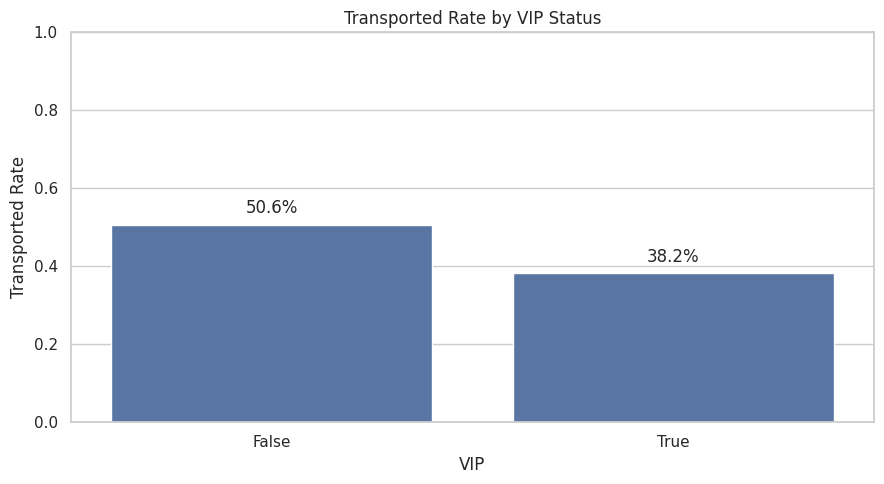

In [14]:
section("10. VIP STATUS AND TRANSPORTED")

vip_counts = df["VIP"].value_counts()
print("VIP counts:")
print(vip_counts)

transported_by_vip = df.groupby("VIP")["Transported"].mean()
print("\nTransported rate by VIP status:")
for status, rate in transported_by_vip.items():
    print(f"{status}: {rate * 100:.1f}%")

plt.figure()
ax = sns.barplot(
    x=transported_by_vip.index,
    y=transported_by_vip.values
)

plt.title("Transported Rate by VIP Status")
plt.xlabel("VIP")
plt.ylabel("Transported Rate")
plt.ylim(0, 1)

for i, value in enumerate(transported_by_vip.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "VIP passengers make up a small fraction of the dataset. Their "
    "transported rate differs somewhat from non-VIP passengers, but "
    "the small sample size means this should be interpreted cautiously."
)

## 12. SPENDING DISTRIBUTIONS


11. ONBOARD SPENDING DISTRIBUTIONS

Spending summary statistics:
        RoomService     FoodCourt  ShoppingMall           Spa        VRDeck
count   8512.000000   8510.000000   8485.000000   8510.000000   8505.000000
mean     224.687617    458.077203    173.729169    311.138778    304.854791
std      666.717663   1611.489240    604.696458   1136.705535   1145.717189
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000      0.000000
50%        0.000000      0.000000      0.000000      0.000000      0.000000
75%       47.000000     76.000000     27.000000     59.000000     46.000000
max    14327.000000  29813.000000  23492.000000  22408.000000  24133.000000

INSIGHT:
All five spending categories are strongly right-skewed: most passengers spent little or nothing, while a small number spent large amounts. This is typical of billing/amenity-spend data.


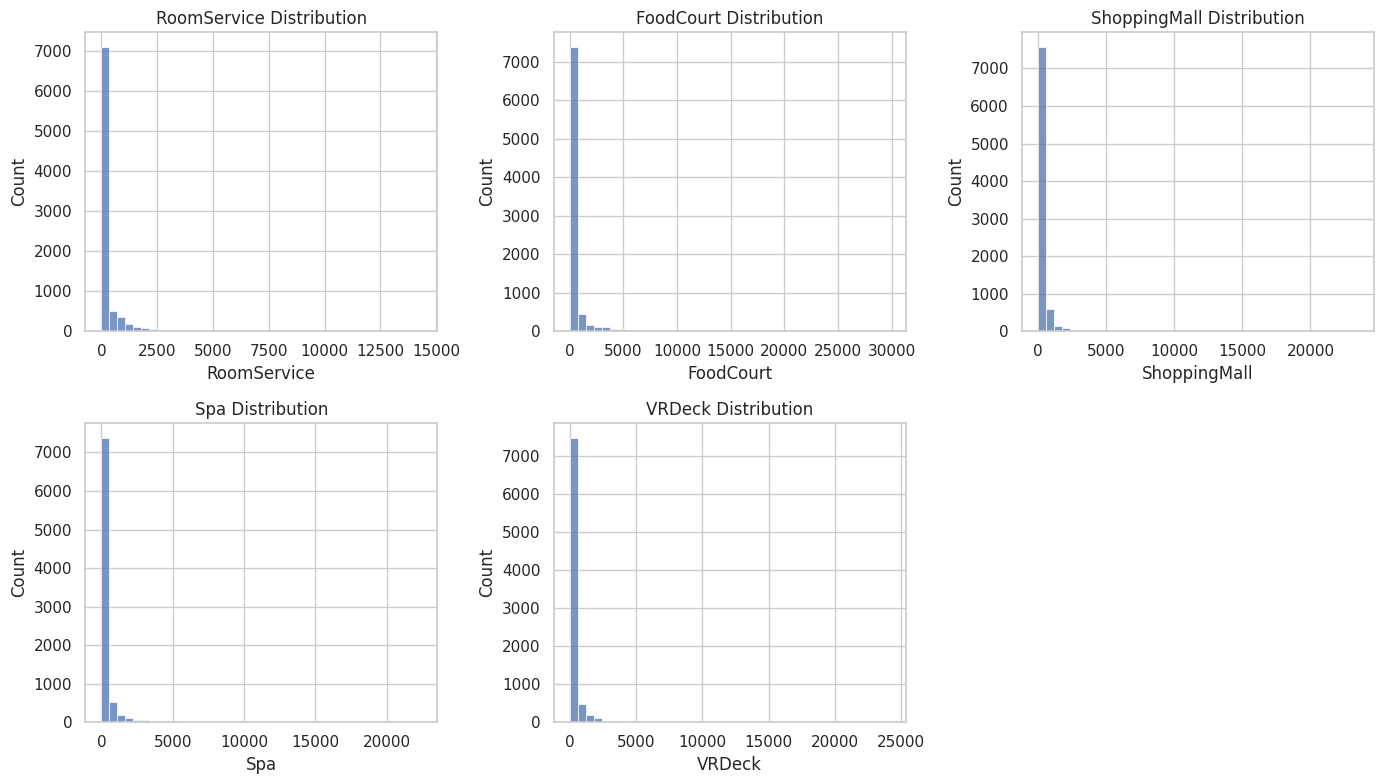

In [15]:
section("11. ONBOARD SPENDING DISTRIBUTIONS")

print("\nSpending summary statistics:")
print(df[SPEND_COLS].describe())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SPEND_COLS):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

axes[-1].axis("off")

show_plot()

print("\nINSIGHT:")
print(
    "All five spending categories are strongly right-skewed: most "
    "passengers spent little or nothing, while a small number spent "
    "large amounts. This is typical of billing/amenity-spend data."
)

## 13. TOTAL SPENDING VS TRANSPORTED


12. TOTAL SPENDING AND TRANSPORTED
                    mean  median
Transported                     
False        2004.149247   907.0
True          885.689127     0.0

INSIGHT:
Passengers who were NOT transported tended to have higher total onboard spending. This lines up with the CryoSleep finding, since passengers in CryoSleep cannot make onboard purchases at all.


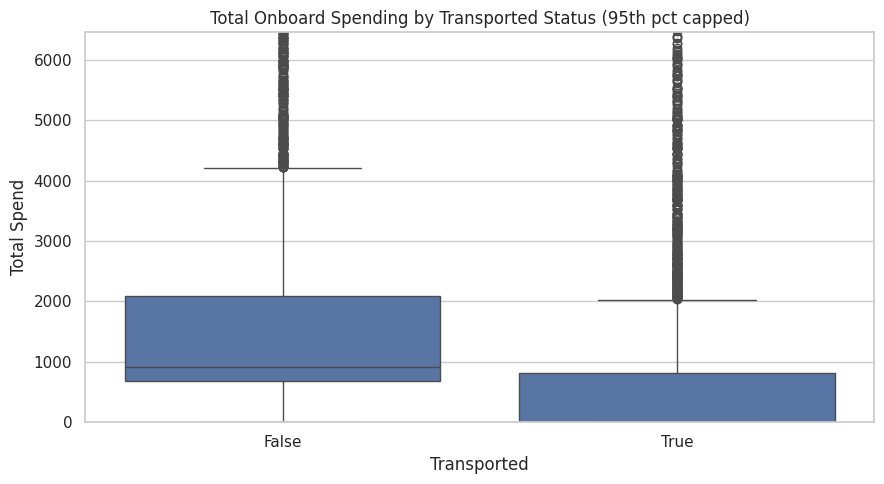

In [16]:
section("12. TOTAL SPENDING AND TRANSPORTED")

df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, skipna=True)

spend_summary = df.groupby("Transported")["TotalSpend"].agg(
    ["mean", "median"]
)

print(spend_summary)

plt.figure()
sns.boxplot(
    data=df,
    x="Transported",
    y="TotalSpend"
)
plt.ylim(0, df["TotalSpend"].quantile(0.95))

plt.title("Total Onboard Spending by Transported Status (95th pct capped)")
plt.xlabel("Transported")
plt.ylabel("Total Spend")

show_plot()

print("\nINSIGHT:")
print(
    "Passengers who were NOT transported tended to have higher total "
    "onboard spending. This lines up with the CryoSleep finding, since "
    "passengers in CryoSleep cannot make onboard purchases at all."
)

## 14. CABIN DECK AND SIDE


13. CABIN DECK AND SIDE
Passengers by deck:
Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

INSIGHT:
Transported rate varies by cabin deck, with decks B and C showing higher rates than deck T or F. Cabin location may be capturing some of the same signal as home planet.


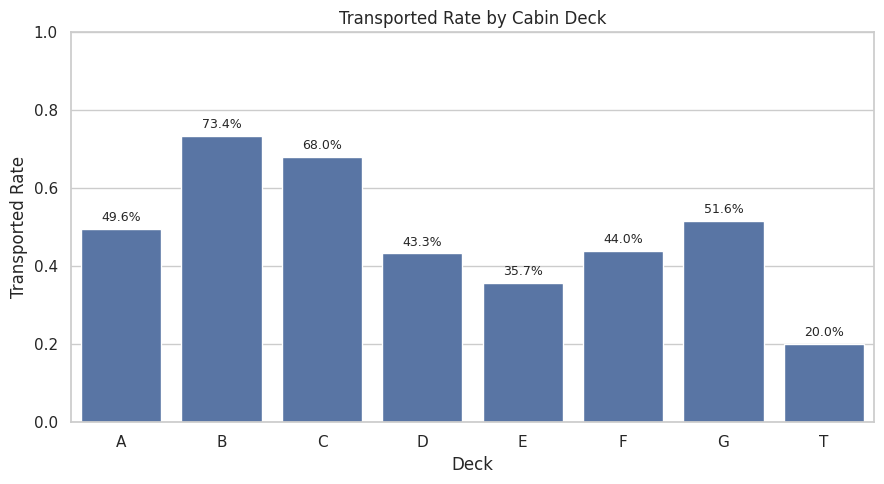

In [17]:
section("13. CABIN DECK AND SIDE")

cabin_split = df["Cabin"].str.split("/", expand=True)
df["Deck"] = cabin_split[0]
df["CabinSide"] = cabin_split[2]

print("Passengers by deck:")
print(df["Deck"].value_counts())

transported_by_deck = df.groupby("Deck")["Transported"].mean().sort_index()

plt.figure()
ax = sns.barplot(
    x=transported_by_deck.index,
    y=transported_by_deck.values,
    order=sorted(df["Deck"].dropna().unique())
)

plt.title("Transported Rate by Cabin Deck")
plt.xlabel("Deck")
plt.ylabel("Transported Rate")
plt.ylim(0, 1)

for i, value in enumerate(transported_by_deck.values):
    ax.text(i, value + 0.02, f"{value * 100:.1f}%", ha="center", fontsize=9)

show_plot()

print("\nINSIGHT:")
print(
    "Transported rate varies by cabin deck, with decks B and C showing "
    "higher rates than deck T or F. Cabin location may be capturing "
    "some of the same signal as home planet."
)

## 15. CORRELATION HEATMAP


14. CORRELATION ANALYSIS

Correlation matrix:
               Age  RoomService  FoodCourt  ...  VRDeck  TotalSpend  Transported
Age           1.00         0.07       0.13  ...    0.10        0.19        -0.08
RoomService   0.07         1.00      -0.02  ...   -0.02        0.24        -0.24
FoodCourt     0.13        -0.02       1.00  ...    0.23        0.75         0.05
ShoppingMall  0.03         0.05      -0.01  ...   -0.01        0.22         0.01
Spa           0.12         0.01       0.22  ...    0.15        0.60        -0.22
VRDeck        0.10        -0.02       0.23  ...    1.00        0.59        -0.21
TotalSpend    0.19         0.24       0.75  ...    0.59        1.00        -0.20
Transported  -0.08        -0.24       0.05  ...   -0.21       -0.20         1.00

[8 rows x 8 columns]

INSIGHT:
Spending variables correlate positively with each other and with TotalSpend by construction. TotalSpend has a negative correlation with Transported, consistent with the earlier finding that Cr

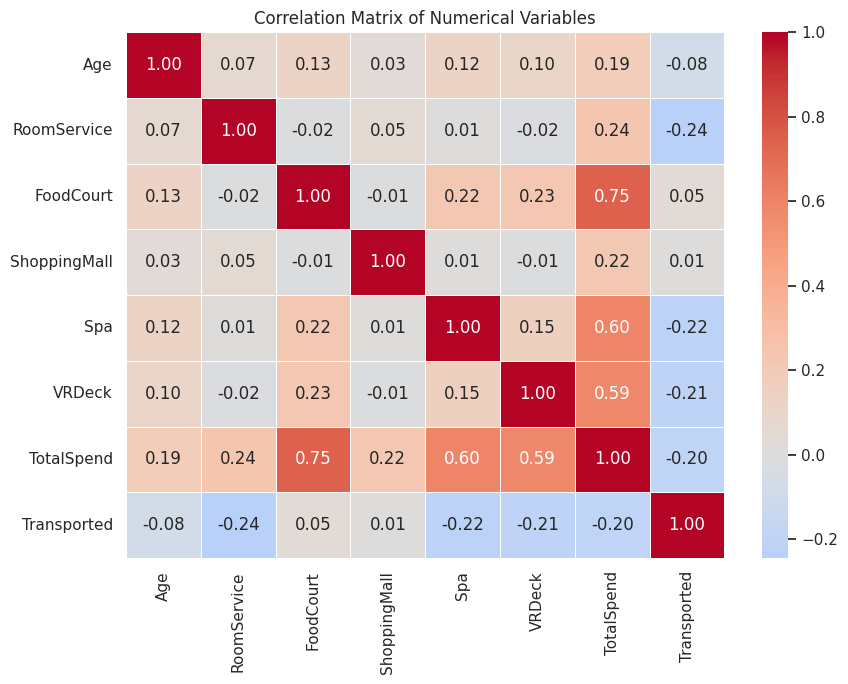

In [18]:
section("14. CORRELATION ANALYSIS")

numeric_columns = ["Age"] + SPEND_COLS + ["TotalSpend"]

correlation_df = df[numeric_columns].copy()
correlation_df["Transported"] = df["Transported"].astype(int)

correlation = correlation_df.corr()

print("\nCorrelation matrix:")
print(correlation.round(2))

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

show_plot()

print("\nINSIGHT:")
print(
    "Spending variables correlate positively with each other and with "
    "TotalSpend by construction. TotalSpend has a negative correlation "
    "with Transported, consistent with the earlier finding that "
    "CryoSleep passengers spend nothing and are transported more often."
)
print(
    "Correlation measures linear association and does not imply causation."
)

## 16. HOME PLANET + CRYOSLEEP + TRANSPORTED


15. HOME PLANET + CRYOSLEEP + TRANSPORTED

Transported rates (%):
CryoSleep   False  True 
HomePlanet              
Earth        32.1   65.6
Europa       40.0   98.9
Mars         27.7   91.2

INSIGHT:
Combining HomePlanet and CryoSleep shows that CryoSleep drives a large jump in transported rate within every home planet group. The two variables together carry more information than either alone.


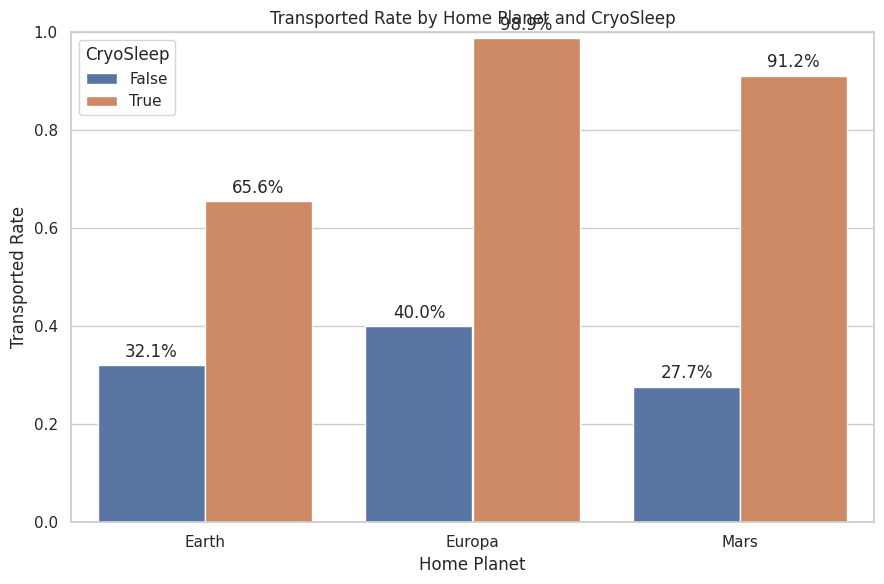

In [19]:
section("15. HOME PLANET + CRYOSLEEP + TRANSPORTED")

combined = (
    df.groupby(["HomePlanet", "CryoSleep"])["Transported"]
    .mean()
    .reset_index()
)

pivot = combined.pivot(
    index="HomePlanet",
    columns="CryoSleep",
    values="Transported"
) * 100

print("\nTransported rates (%):")
print(pivot.round(1))

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=combined,
    x="HomePlanet",
    y="Transported",
    hue="CryoSleep"
)

plt.title("Transported Rate by Home Planet and CryoSleep")
plt.xlabel("Home Planet")
plt.ylabel("Transported Rate")
plt.ylim(0, 1)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        labels.append(
            "" if np.isnan(height)
            else f"{height * 100:.1f}%"
        )
    ax.bar_label(container, labels=labels, padding=3)

show_plot()

print("\nINSIGHT:")
print(
    "Combining HomePlanet and CryoSleep shows that CryoSleep drives a "
    "large jump in transported rate within every home planet group. "
    "The two variables together carry more information than either "
    "alone."
)

## 17. FINAL SUMMARY

In [20]:
section("16. FINAL EDA SUMMARY")

print(
    f"""
Dataset:
- {len(df)} passengers
- {df.shape[1]} columns (after added TotalSpend/Deck/CabinSide features)

Data quality:
- Missing values are spread across most columns at roughly 2% each.
- No single column dominates the missing-data problem.

Target:
- Overall transported rate: {transported_rate * 100:.1f}%
- Classes are close to balanced.

Key associations with Transported:
1. CryoSleep shows the strongest association: passengers in CryoSleep
   are transported far more often.
2. HomePlanet shows a clear association, with Europa higher than Earth.
3. Total onboard spending is negatively associated with being
   transported, largely overlapping with the CryoSleep effect.
4. Cabin deck shows some variation, potentially related to HomePlanet.
5. Age and VIP status show weaker relationships with the target.

Overall:
CryoSleep and HomePlanet are the most important variables to
investigate further, followed by spending behavior and cabin deck.

Important:
EDA identifies patterns and associations. It does not prove that a
variable directly caused a passenger to be transported.
"""
)

print("=" * 75)
print("EDA COMPLETE")
print("=" * 75)


16. FINAL EDA SUMMARY

Dataset:
- 8693 passengers
- 17 columns (after added TotalSpend/Deck/CabinSide features)

Data quality:
- Missing values are spread across most columns at roughly 2% each.
- No single column dominates the missing-data problem.

Target:
- Overall transported rate: 50.4%
- Classes are close to balanced.

Key associations with Transported:
1. CryoSleep shows the strongest association: passengers in CryoSleep
   are transported far more often.
2. HomePlanet shows a clear association, with Europa higher than Earth.
3. Total onboard spending is negatively associated with being
   transported, largely overlapping with the CryoSleep effect.
4. Cabin deck shows some variation, potentially related to HomePlanet.
5. Age and VIP status show weaker relationships with the target.

Overall:
CryoSleep and HomePlanet are the most important variables to
investigate further, followed by spending behavior and cabin deck.

Important:
EDA identifies patterns and associations. It does